# Graphing

## Imports

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Imports required libraries for this notebook

## Data

In [37]:
mergedDataLocation = r"ModifiedData/GraphingData.csv"
graphOutputLocation = r"Visualizations/"

Creates easily editable variables with the locations of various datasets and folders

In [38]:
MergedDF = pd.read_csv(mergedDataLocation, index_col=0)
MergedDF

,Country name,Year,Code,"GDP per capita, PPP (constant 2021 international $)",Life evaluation (3-year average),Rank,Lower whisker,Upper whisker,Explained by: Log GDP per capita,Explained by: Social support,Explained by: Healthy life expectancy,Explained by: Freedom to make life choices,Explained by: Generosity,Explained by: Perceptions of corruption,Dystopia + residual,Predicted Happiness
0,Finland,2023,FIN,57063.5230,7.741,1,7.667,7.815,1.844,1.572,0.695,0.859,0.142,0.546,2.082,6.501796
1,Denmark,2023,DNK,72097.3050,7.583,2,7.500,7.665,1.908,1.520,0.699,0.823,0.204,0.548,1.881,6.992854
2,Iceland,2023,ISL,67255.6700,7.525,3,7.433,7.618,1.881,1.617,0.718,0.819,0.258,0.182,2.050,6.834709
3,Sweden,2023,SWE,63114.6800,7.344,4,7.267,7.422,1.878,1.501,0.724,0.838,0.221,0.524,1.658,6.699449
4,Israel,2023,ISR,48432.1100,7.341,5,7.277,7.405,1.803,1.513,0.740,0.641,0.153,0.193,2.298,6.219863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1760,Burundi,2011,BDI,951.1885,3.678,152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.668965
1761,Sierra Leone,2011,SLE,2471.7185,3.586,153,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.718631
1762,Central African Republic,2011,CAF,1517.1484,3.568,154,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.687451
1763,Benin,2011,BEN,2732.0125,3.493,155,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.727133


Loads the merged data into a Pandas DataFrame object and displays it

## Graph generation

### Plot of GDP per capita and Real Happiness Score and Predicted Happiness Score

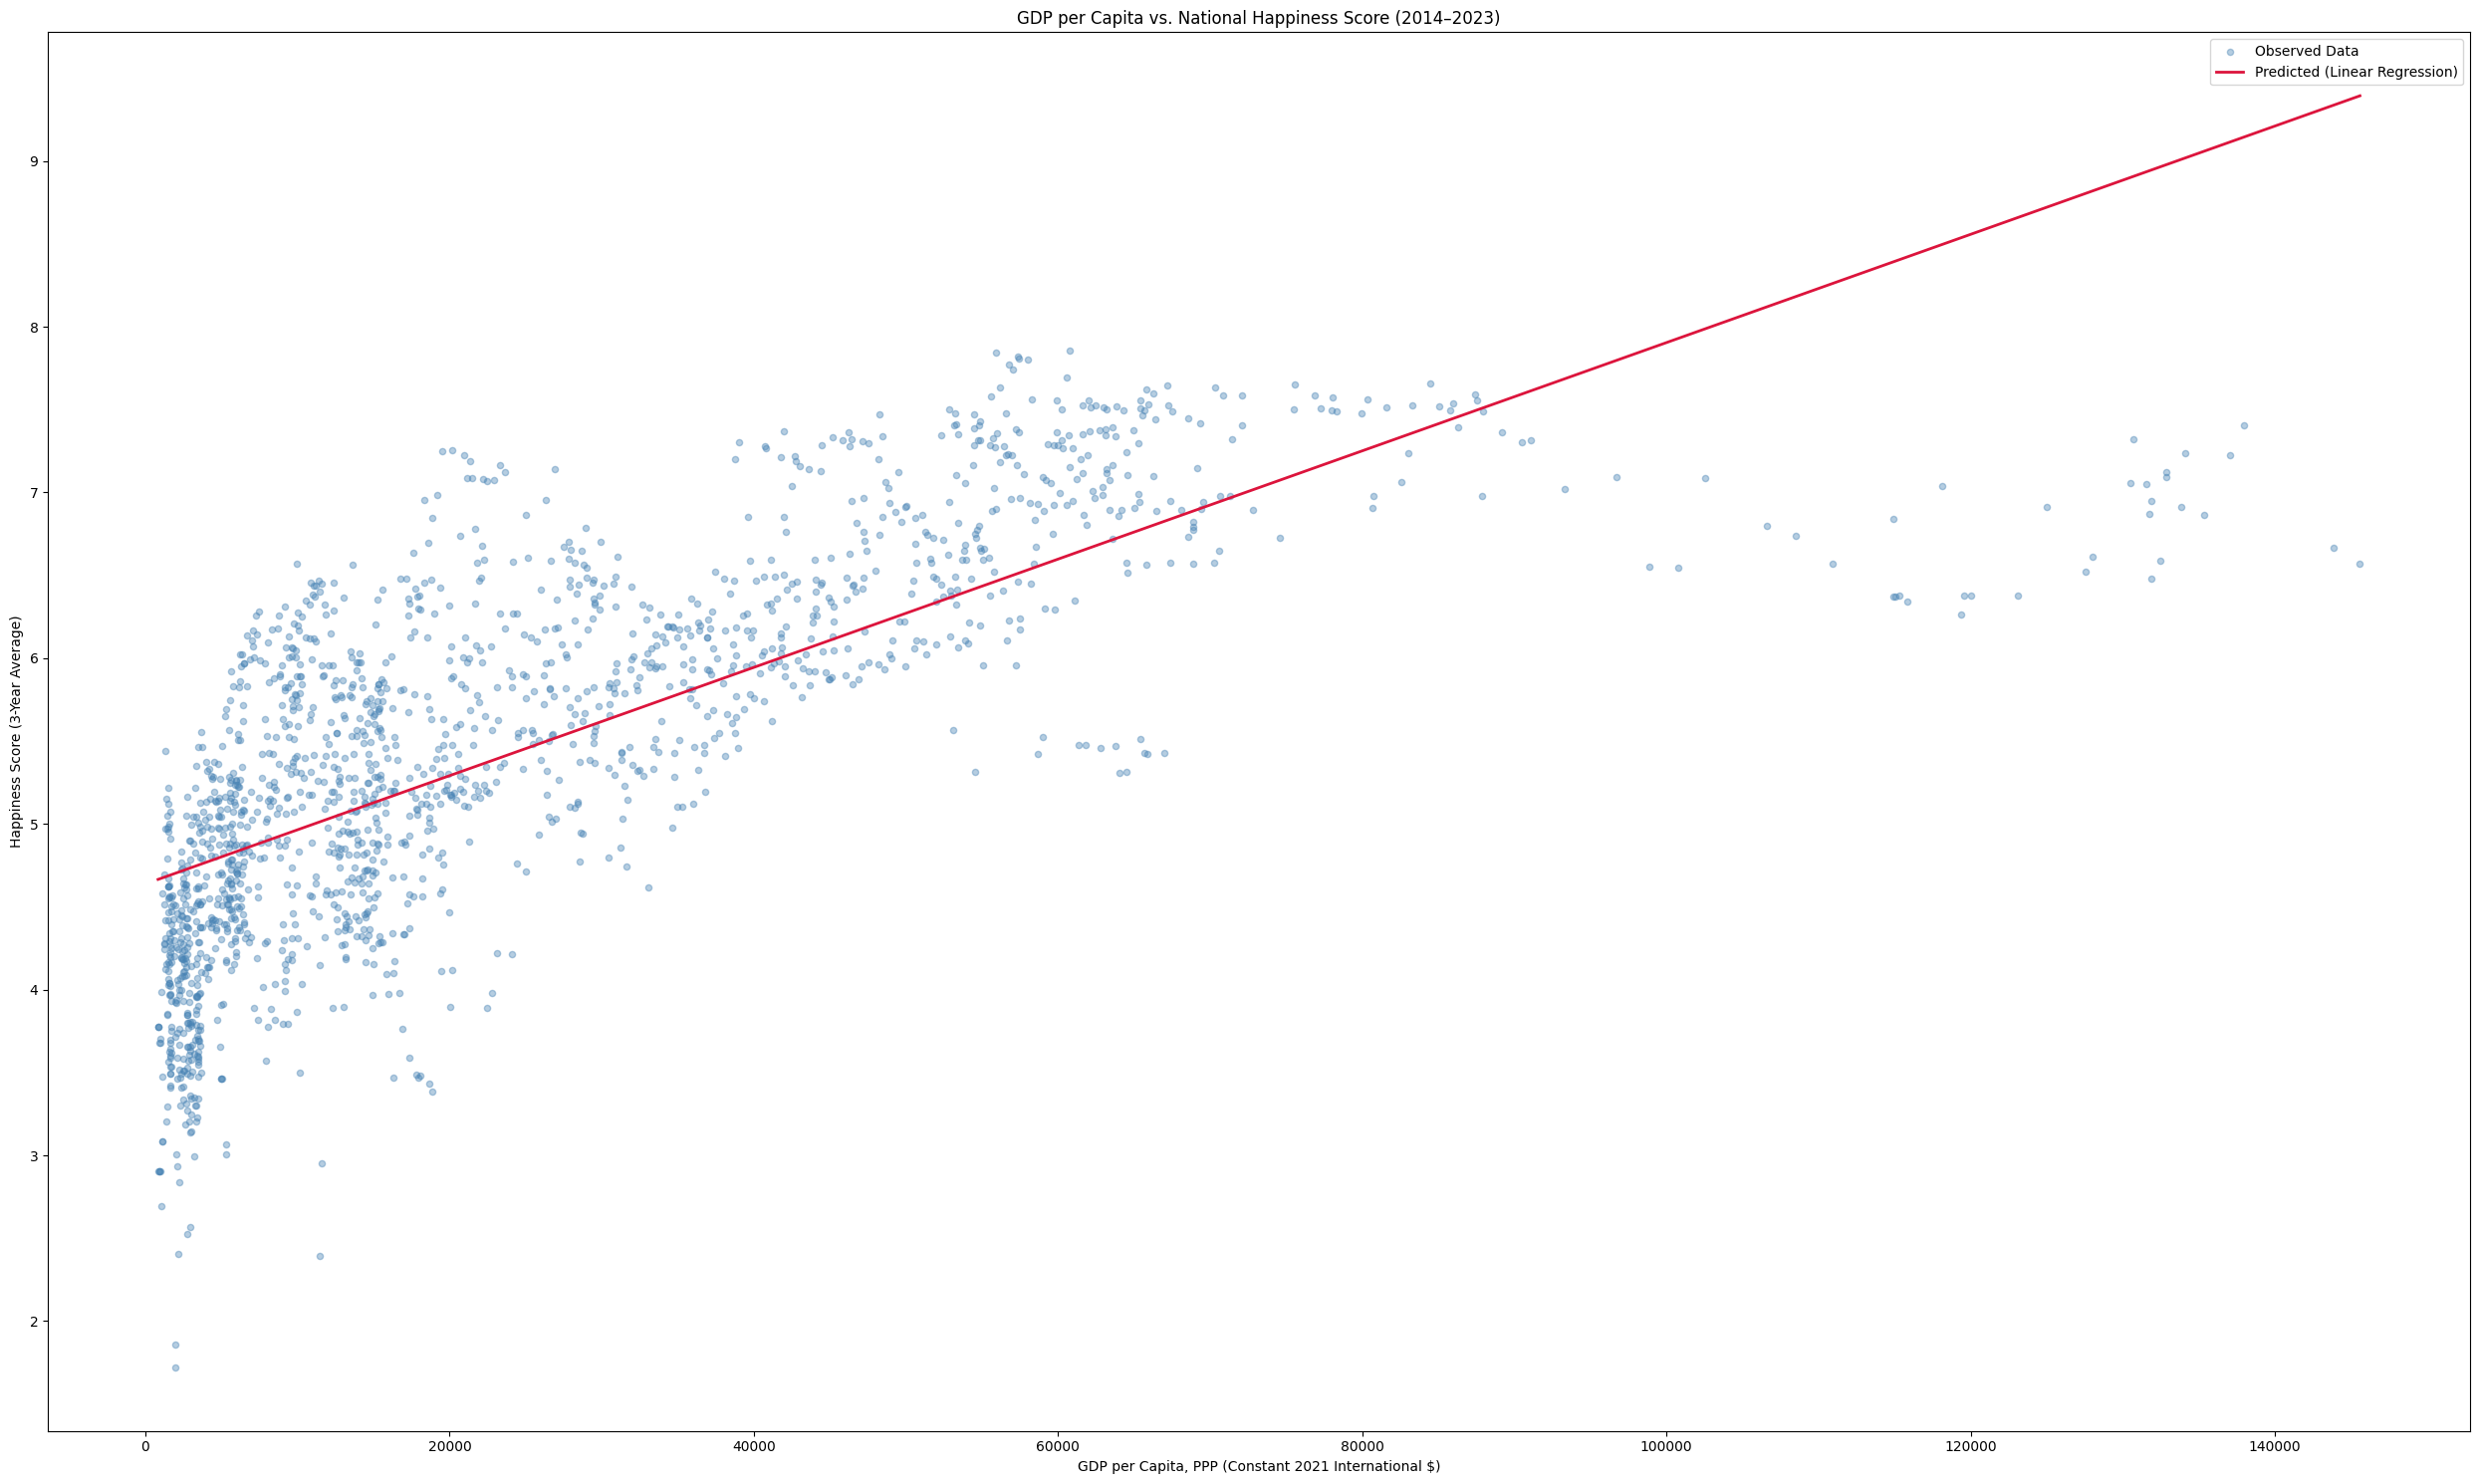

In [ ]:
# AI Disclaimer: Anthropic's Claude was used in formatting the graph

fig, ax = plt.subplots(figsize=(25,15))

ax.scatter(
    MergedDF["GDP per capita, PPP (constant 2021 international $)"],
    MergedDF["Life evaluation (3-year average)"],
    alpha=0.4, s=20, color="steelblue", label="Observed Data"
)

sorted_df = MergedDF.sort_values("GDP per capita, PPP (constant 2021 international $)")
ax.plot(
    sorted_df["GDP per capita, PPP (constant 2021 international $)"],
    sorted_df["Predicted Happiness"],
    color="crimson", linewidth=2, label="Predicted (Linear Regression)"
)

ax.set_xlabel("GDP per Capita, PPP (Constant 2021 International $)")
ax.set_ylabel("Happiness Score (3-Year Average)")
ax.set_title("GDP per Capita vs. National Happiness Score (2014–2023)")
ax.legend()

plt.tight_layout()
plt.savefig(graphOutputLocation + "gdp_vs_happiness.png")
plt.show()

Creates, saves, and shows a scatterplot of GDP per capita vs Happiness, and the predicted value/Best fit line that the linear regression output. The graph suggests that there is a positive trend with increasing GDP per capita and reported Happiness. It seems that there is a lot of variation at lower GDP per capita values, while the prediction starts to consistently overestimate the impact of GDP on happiness at high GDP per capita values. This suggests that as basic needs are met, other factors begin to play a much heavier role that increasing wealth. Perhaps adding other dimensions such as Wealth disparity or perceived fairness would help improve the quality of the model while focusing on economic data.

### Histogram of Regression residuals

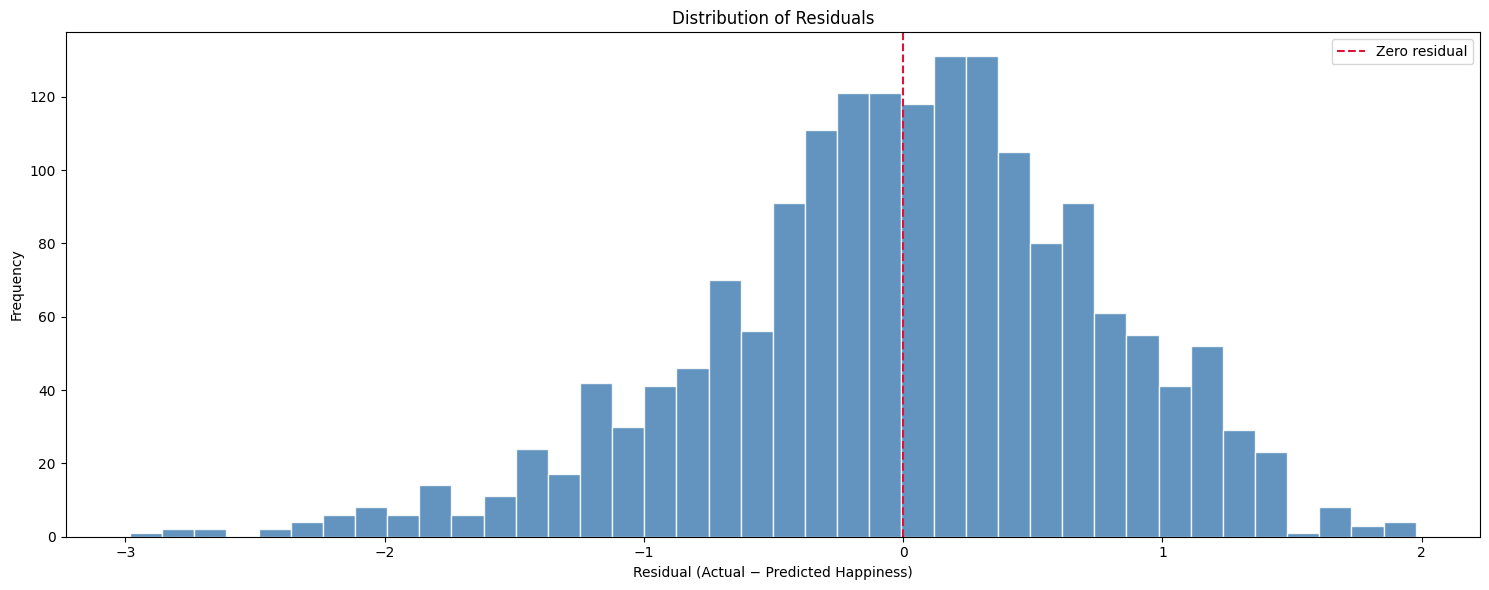

In [ ]:
# AI Disclaimer: Anthropic's Claude was used in formatting the graph, and brainstorming the idea for this graph

MergedDF["Residuals"] = MergedDF["Life evaluation (3-year average)"] - MergedDF["Predicted Happiness"]

fig, ax = plt.subplots(figsize=(15, 6))

ax.hist(MergedDF["Residuals"], bins=40, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(0, color="crimson", linewidth=1.5, linestyle="--", label="Zero residual")

ax.set_xlabel("Residual (Actual − Predicted Happiness)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of Residuals")
ax.legend()

plt.tight_layout()
plt.savefig(graphOutputLocation + "residuals_histogram.png")
plt.show()

This plot shows that the residuals somewhat follow a Normal distribution, but with a clear negative skew. This is not perfectly in line with the assumption of normally distributed residuals in a linear regression, suggesting that something is not included in the model.

### Residuals Plot

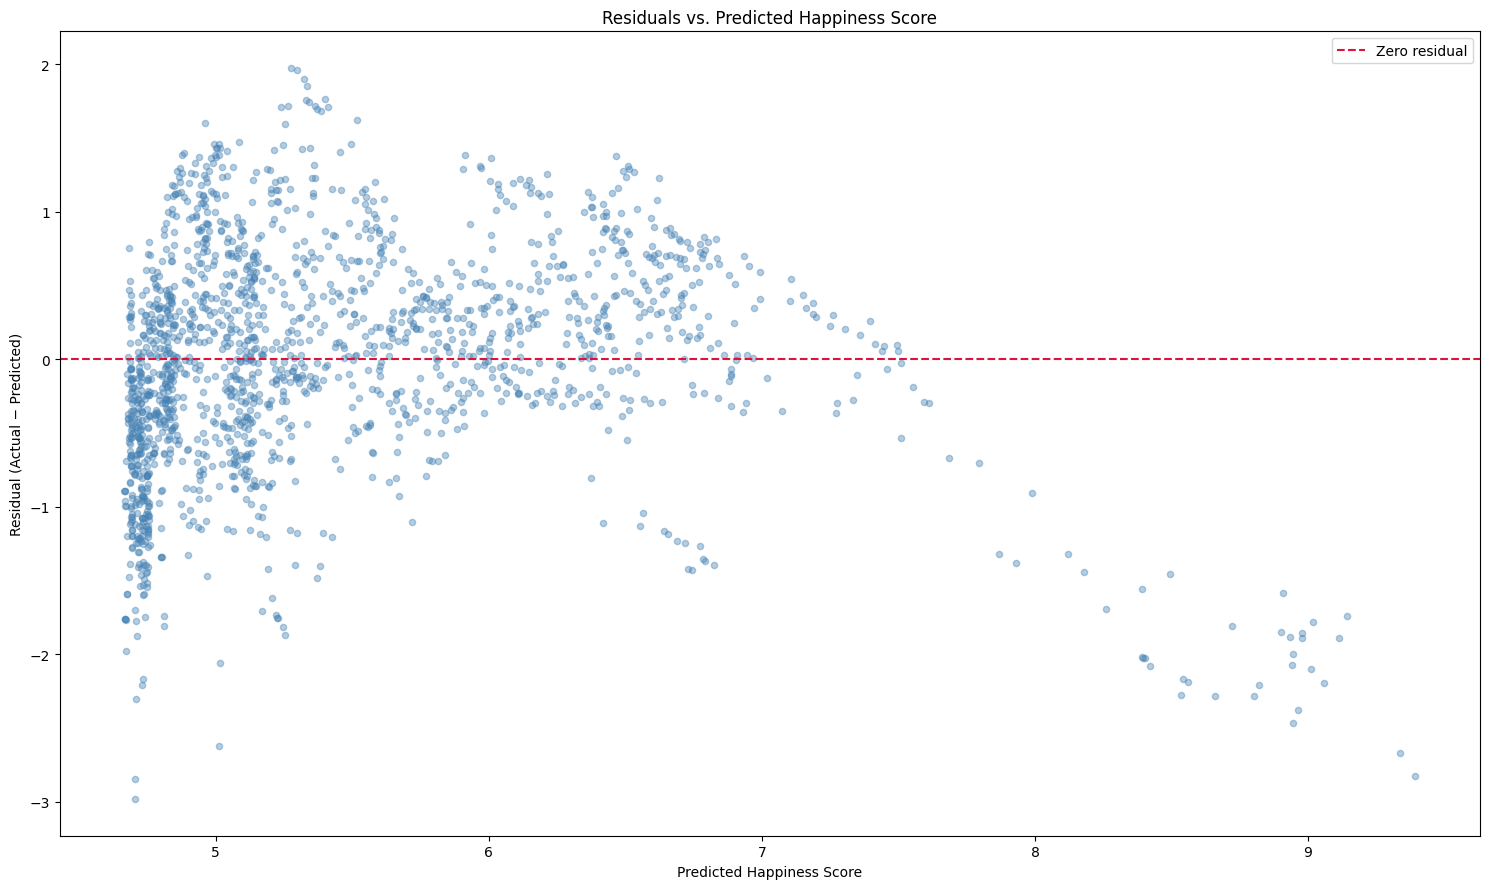

In [ ]:
# AI Disclaimer: Anthropic's Claude was used in formatting the graph, and brainstorming the idea for this graph

fig, ax = plt.subplots(figsize=(15, 9))

ax.scatter(
    MergedDF["Predicted Happiness"],
    MergedDF["Residuals"],
    alpha=0.4, s=20, color="steelblue"
)
ax.axhline(0, color="crimson", linewidth=1.5, linestyle="--", label="Zero residual")

ax.set_xlabel("Predicted Happiness Score")
ax.set_ylabel("Residual (Actual − Predicted)")
ax.set_title("Residuals vs. Predicted Happiness Score")
ax.legend()

plt.tight_layout()
plt.savefig(graphOutputLocation + "residuals_plot.png")
plt.show()

This plot is another check of the residuals from the linear regression. The graph suggests that the residuals are more normally distributed at lower happiness scores, which is associated with lower GDP per capita. The inaccuracy at higher GDP per capita seems to be driving the negative skew of the residuals, again indicating that other factors begin to overtake wealth as wealth reaches a point of comfortability.

### Average Happiness per year (Of all reporting countries)

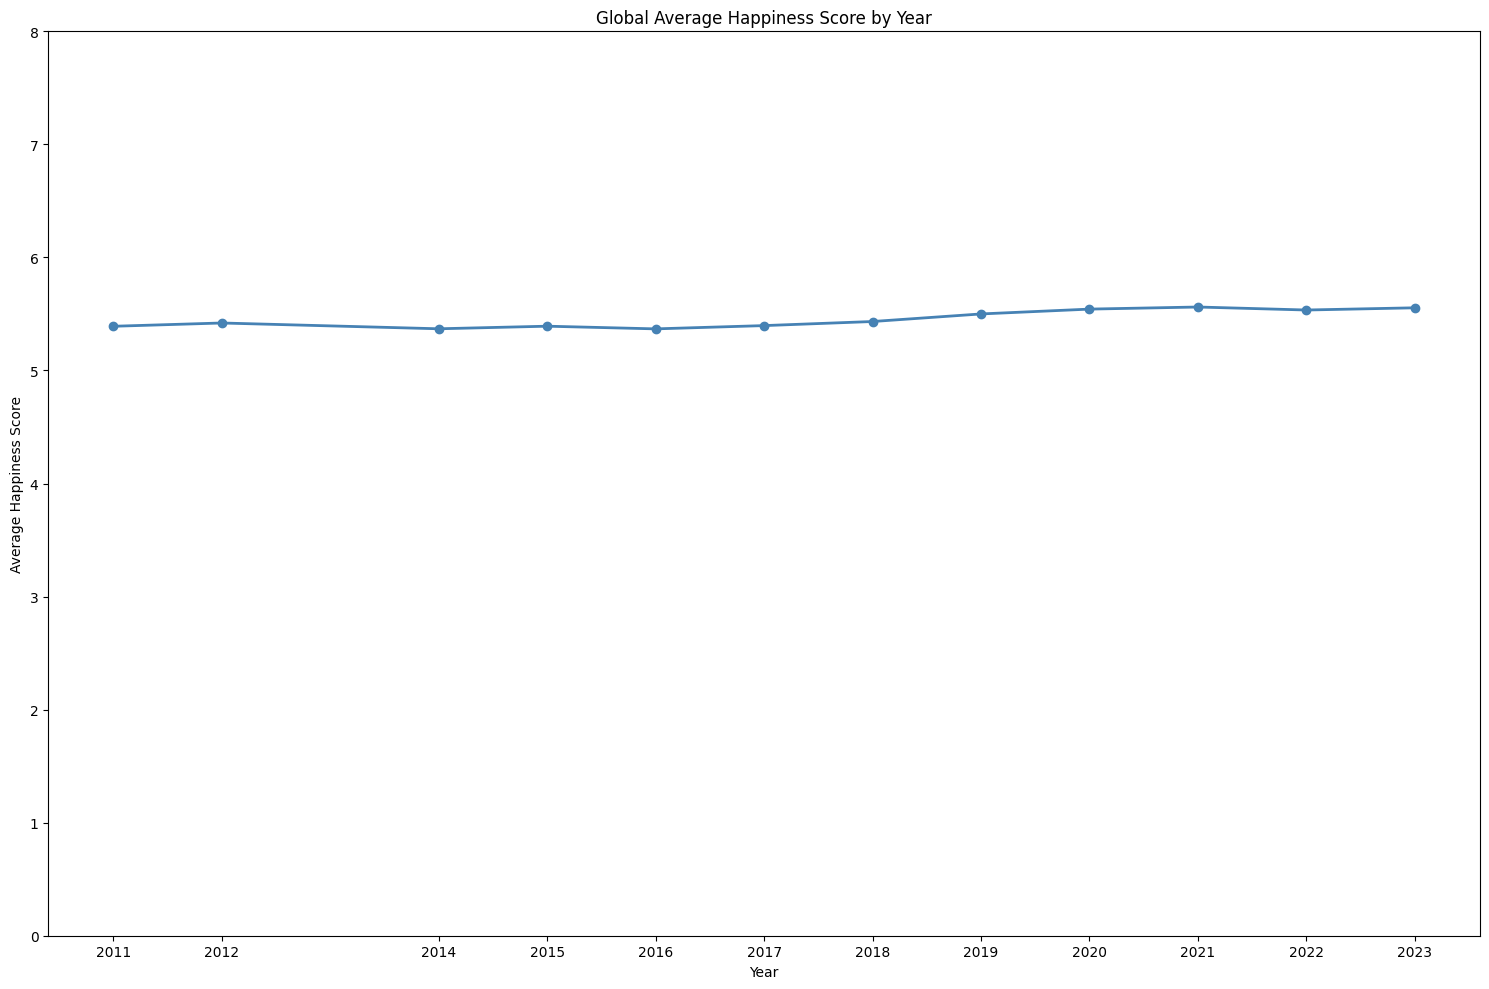

In [ ]:
# AI Disclaimer: Anthropic's Claude was used in formatting the graph

yearly_avg = (MergedDF.groupby("Year")["Life evaluation (3-year average)"].mean())

fig, ax = plt.subplots(figsize=(15, 10))

ax.plot(yearly_avg.index, yearly_avg.values, marker="o", color="steelblue",linewidth=2, markersize=6)

ax.set_xlabel("Year")
ax.set_ylabel("Average Happiness Score")
ax.set_title("Global Average Happiness Score by Year")
ax.set_xticks(yearly_avg.index)
ax.set_ylim(0, 8)

plt.tight_layout()
plt.savefig(graphOutputLocation + "avg_happiness_by_year.png")
plt.show()

The output plot shows that the average happiness of reporting countries has not significantly changed from 2011–2023. This is somewhat surprising, as pandemic conditions in 2020 seemed to have minimal effect on the 3 year average.